# Appendix - Datasets: Defining the Final Dataset

In [18]:
# load libraries
import pandas as pd
import numpy as np

## For Visualizing
import matplotlib.pyplot as plt

In [19]:
all_data = pd.read_csv("all_data.csv")

### College Town Size Distribution
College Town Size Distribution
Examining the population size distribution of college towns we see that it is very heavily left-skewed. Additionally, there are a few outliers far to the right (very large populations).

Reducing our definition of College towns to not include those in the top five percentile by size, we reduce the number of samples from 717 to 681 and reduce the largest College Town population from 1,680,992 to 282,011 (which is in better keeping with the standard definition of a college town).

In [20]:
all_data_w_p = all_data.loc[ (all_data.pop_2019 > 0) ].copy()

In [21]:
all_data_w_c = all_data.loc[ (all_data.colleges_count > 0) & (all_data.pop_2019 > 0) ].copy()
print( "Smallest college town 2019 population: {:.0f}".format(all_data_w_c.pop_2019.min() ) )
print( "Largest college town 2019 population: {:.0f}".format(all_data_w_c.pop_2019.max() ) )

Smallest college town 2019 population: 672
Largest college town 2019 population: 1680992


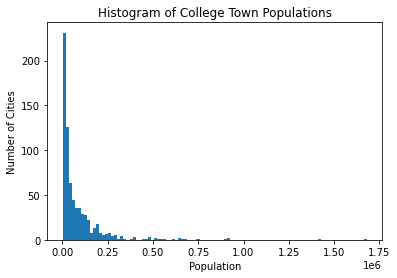

In [22]:
plt.title('Histogram of College Town Populations')
plt.xlabel('Population')
plt.ylabel('Number of Cities')
plt.hist(all_data_w_c.pop_2019, bins=100)
plt.show()

In [23]:
ninetyfive_ct = all_data_w_c.loc[ (all_data.pop_2019 <= all_data_w_c.pop_2019.quantile(.95)) ]

In [24]:
print( "Smallest college town 2019 population (lower 95%): {:.0f}".format( ninetyfive_ct.pop_2019.min() ) )
print( "Largest college town 2019 population (lower 95%): {:.0f}".format( ninetyfive_ct.pop_2019.max() ) )
print( "College towns with 2019 population (lower 95%): {:.0f}".format( ninetyfive_ct.pop_2019.count() ) )

Smallest college town 2019 population (lower 95%): 672
Largest college town 2019 population (lower 95%): 282011
College towns with 2019 population (lower 95%): 685


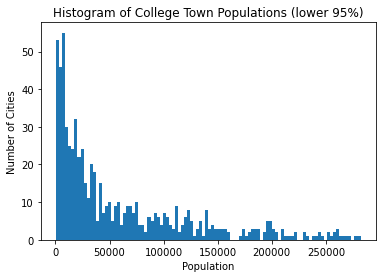

In [25]:
plt.title('Histogram of College Town Populations (lower 95%)')
plt.xlabel('Population')
plt.ylabel('Number of Cities')
plt.hist(ninetyfive_ct.pop_2019, bins=100)
plt.show()

## Comparing similarly sized Cities

From here forward, when comparing college town populations to the larger population data I will limit the dataset to cities with a known population of less than 285,000 so as to be comparing like samples.

In [26]:
all_data = all_data.drop(columns=['Unnamed: 0'])

In [27]:
ninetyfive_ct.pop_2019.max()

282011.0

In [61]:
# all_data.loc[ ( all_data.pop_2019 == ( (all_data.pop_2019 < 285000).max() ) ) ]
all_data.loc[ ( all_data.pop_2019 < 285000 ) & (all_data['2020-09-30'] > 0)]

,SizeRank,city,1996-01-31,1996-02-29,1996-03-31,1996-04-30,1996-05-31,1996-06-30,1996-07-31,1996-08-31,...,pop_2012,pop_2013,pop_2014,pop_2015,pop_2016,pop_2017,pop_2018,pop_2019,colleges,colleges_count
52,52,Knoxville,99599,99881,100134,100555,100909,101327,101728,102191,...,181093.0,181779.0,182631.0,184046.0,184986.0,186905.0,187362.0,187603.0,"['University of Tennessee', 'Duncan School of ...",2
53,53,Baton Rouge,0,0,0,0,0,0,0,0,...,228889.0,228346.0,227851.0,227202.0,226686.0,224414.0,222190.0,220236.0,"['Louisiana State University', 'Southern Unive...",3
63,64,Columbia,90962,91033,91094,91250,91368,91484,91589,91821,...,131761.0,131527.0,131781.0,133616.0,134129.0,134005.0,132770.0,131674.0,['University of South Carolina'],1
65,66,Marietta,147940,148096,148384,148971,149705,150394,150972,151473,...,58167.0,58819.0,59547.0,59845.0,60679.0,60679.0,60647.0,60867.0,[],0
66,67,Vancouver,137854,138387,138657,139305,140274,141799,143911,146065,...,170035.0,171565.0,173406.0,176409.0,178621.0,180360.0,182887.0,184463.0,['Washington State University Vancouver'],1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26396,29449,Beaver Bay,0,0,0,0,0,0,0,0,...,177.0,174.0,172.0,170.0,169.0,169.0,170.0,171.0,[],0
26397,29449,Duffield,0,0,0,0,0,0,0,0,...,89.0,88.0,87.0,86.0,85.0,84.0,83.0,83.0,[],0
26399,29449,Mosby,0,0,0,0,0,0,0,0,...,195.0,197.0,198.0,196.0,197.0,198.0,199.0,200.0,[],0
26400,29449,Junior,0,0,0,0,0,0,0,0,...,516.0,511.0,508.0,505.0,497.0,491.0,490.0,486.0,[],0


In [65]:
# dataset = all_data.loc[ (all_data.SizeRank <= int(max_size_rank.SizeRank)) ]
# ninetyfive_ct.head(50)
all_data.loc[ (all_data.pop_2019 == (all_data.pop_2019 <= 285000).max() ) ]
all_data[['SizeRank', 'pop_2019']][25:75]

,SizeRank,pop_2019
25,25,651073.0
26,26,692600.0
27,27,705749.0
28,28,654741.0
29,29,670820.0
30,30,513624.0
31,31,593490.0
32,32,590157.0
33,33,531576.0
34,34,478192.0
